In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c  # Speed of light in m/s
# Constants
c_kms = c / 1e3  # Speed of light in km/s
lambda_pa_alpha = 1.875  # Rest-frame wavelength of Pa-alpha in micrometers
lambda_h_beta = 0.4861  # Rest-frame wavelength of H-beta in micrometers

In [2]:
def load_data(filename, cols=3):
    return np.loadtxt(filename, unpack=True, usecols=range(cols))

# Load files
u, v = load_data('../RM Data/base_G.txt', cols=2)

wavelength_pa, flux_pa, err_flux_pa = load_data('../RM Data/spec_data_G.txt', cols=3)
wavelength_phase, phase, err_phase = load_data('../RM Data/phase_data_G.txt', cols=3)

# Convert wavelength to velocity space
velocity_pa = c_kms * (wavelength_pa - lambda_pa_alpha) / lambda_pa_alpha

# Baselines

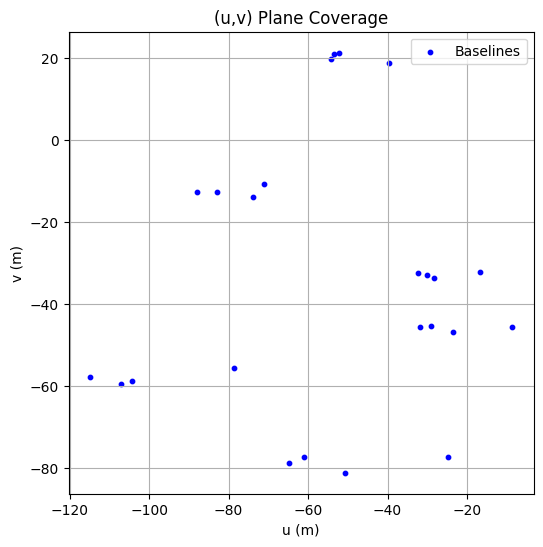

In [3]:
# Plot (u,v) plane coverage
plt.figure(figsize=(6,6))
plt.scatter(u, v, s=10, color='blue', label='Baselines')
plt.xlabel('u (m)')
plt.ylabel('v (m)')
plt.title('(u,v) Plane Coverage')
plt.legend()
plt.grid()
plt.show()

# Pa-alpha line profile

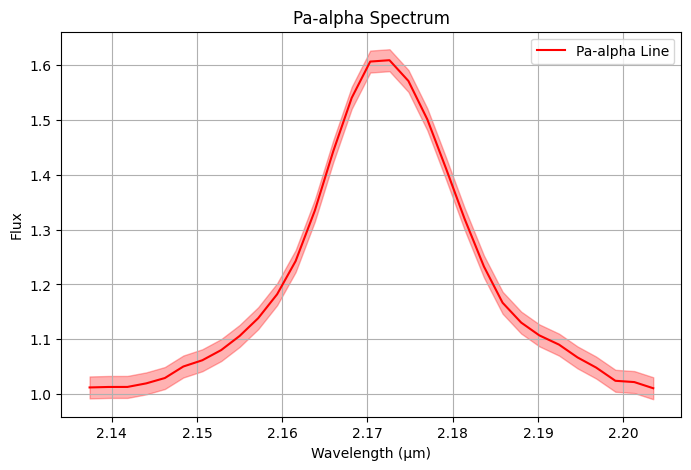

In [4]:
# Plot Pa-alpha spectral line
plt.figure(figsize=(8,5))
plt.plot(wavelength_pa, flux_pa, color='red', label='Pa-alpha Line')
plt.fill_between(wavelength_pa, flux_pa - err_flux_pa, flux_pa + err_flux_pa, color='red', alpha=0.3)
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux')
plt.title('Pa-alpha Spectrum')
plt.legend()
plt.grid()
plt.show()

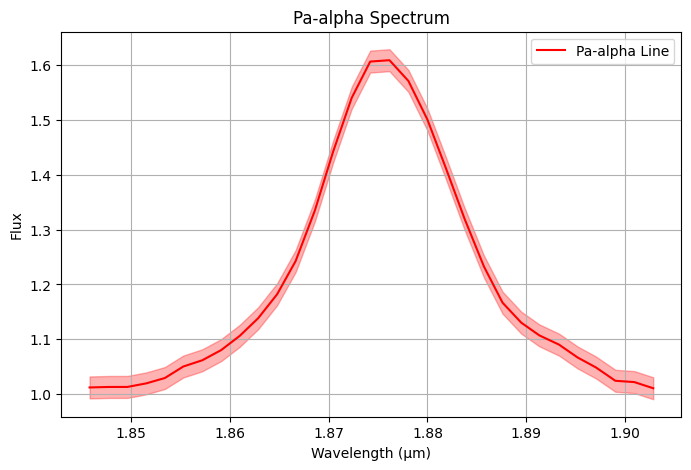

In [64]:
# with a known z=0.158, correct the spectrum to local rest-frame wavelengths
z_correct = lambda wls, z=0.158: wls/(1+z)
z_correct(wavelength_pa)
# Plot Pa-alpha spectral line
plt.figure(figsize=(8,5))
plt.plot(z_correct(wavelength_pa), flux_pa, color='red', label='Pa-alpha Line')
plt.fill_between(z_correct(wavelength_pa), flux_pa - err_flux_pa, flux_pa + err_flux_pa, color='red', alpha=0.3)
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux')
plt.title('Pa-alpha Spectrum')
plt.legend()
plt.grid()
plt.show()

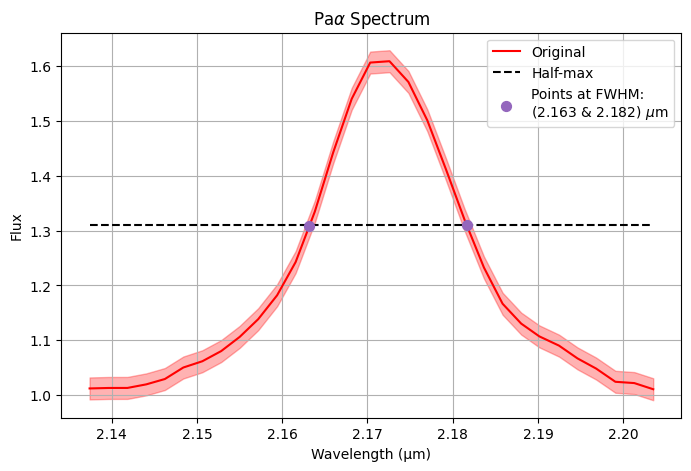

(2949.5548656564238, 0.01844747999999985)

In [97]:
velocity_conversion = lambda wl: c_kms * (wl) / lambda_pa_alpha

def find_fwhm(wls, flux, plot=False):
    # half_max = 0.5 * (np.max(flux) - np.min(flux)) + np.min(flux)
    
    wls_new = np.linspace(wls[0], wls[-1], num=1001)
    flux_new = np.interp(wls_new, wls, flux)
    half_max = 0.5 * (np.max(flux_new) - np.min(flux_new)) + np.min(flux_new)
    
    mid = len(flux_new) // 2
    rising_nearest = np.argmin((flux_new[:mid] - half_max)**2)
    falling_nearest = mid + np.argmin((flux_new[mid:] - half_max)**2)
    
    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(wls, flux, 'r-', label='Original')
        plt.hlines(half_max, wls[0], wls[-1], ls='--', color='black', label='Half-max')
        plt.fill_between(wls, flux - err_flux_pa, flux + err_flux_pa, color='red', alpha=0.3)
        plt.scatter([wls_new[rising_nearest], wls_new[falling_nearest]], 
                   [flux_new[rising_nearest], flux_new[falling_nearest]], 
                   c='tab:purple', s=50, zorder=5, label='Points at FWHM:' "\n" f'({wls_new[rising_nearest]:.3f} & {wls_new[falling_nearest]:.3f}) $\mu$m')
        plt.xlabel('Wavelength (μm)'); plt.ylabel('Flux')
        plt.title(r'Pa$\alpha$ Spectrum'); plt.legend(); plt.grid() 
        plt.savefig('plots/paa-line.png', dpi=600)
        plt.show()
    
    FWHM_wl = wls_new[falling_nearest] - wls_new[rising_nearest]
    dV = velocity_conversion(FWHM_wl)
    return dV, FWHM_wl

find_fwhm(wavelength_pa, flux_pa, plot=True)

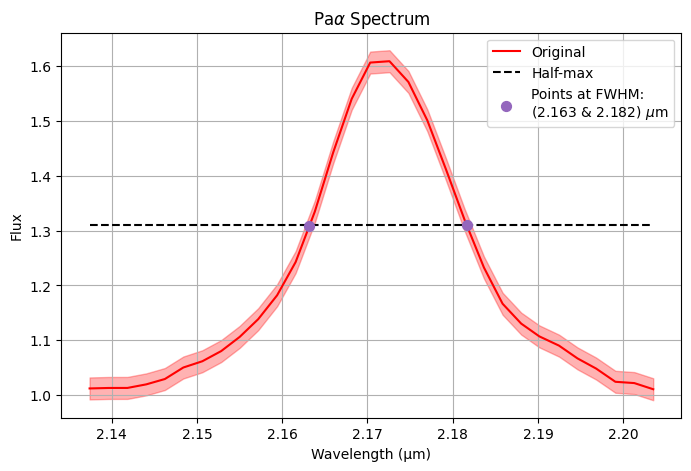

FWHM velocity: 2950 ± 126 km/s
At redshift z=0.158, observed FWHM: 0.0184 μm


In [69]:
# Main computation with MC error propagation
def fwhm_with_error(wls, flux, flux_err, n_mc=1000, plot=False):
    # Central value
    dV_central, FWHM_wl_central = find_fwhm(wls, flux, plot=plot)
    
    # Monte Carlo error propagation
    dV_mc = np.zeros(n_mc)
    for i in range(n_mc):
        # Sample flux from Gaussian errors (preserves correlations)
        flux_sample = np.random.normal(flux, flux_err)
        dV_mc[i], _ = find_fwhm(wls, flux_sample, plot=False)
    
    dV_err = np.std(dV_mc)  # Standard deviation of MC samples
    
    print(f"FWHM velocity: {dV_central:.0f} ± {dV_err:.0f} km/s")
    print(f"At redshift z={0.158:.3f}, observed FWHM: {FWHM_wl_central:.4f} μm")
    
    return dV_central, dV_err

# Run it
dV, dV_err = fwhm_with_error(wavelength_pa, flux_pa, err_flux_pa, n_mc=1000, plot=True)

# Mass estimates

In [87]:
import astropy.units as u
import astropy.constants as c
u.ld = u.lyr/365

R = 215.7 # ld
R_err = 4.7 # ld

In [90]:
M = lambda f, R, dV: (f*(R * dV**2)/c.G).to(1e8*u.solMass)
M(1, R*u.ld, dV*u.km/u.s)

<Quantity 3.66507845 1e+08 solMass>

In [91]:
M_err = lambda f, R, R_err, dV, dV_err: M(f, R, dV) * np.sqrt((R_err/R)**2 + 2*(dV_err/dV)**2)
M_err(1, R*u.ld, R_err*u.ld, dV*u.km/u.s, dV_err*u.km/u.s)

<Quantity 0.23619373 1e+08 solMass>

In [93]:
M(5.5, R*u.ld, dV*u.km/u.s), M_err(5.5, R*u.ld, R_err*u.ld, dV*u.km/u.s, dV_err*u.km/u.s)

(<Quantity 20.15793146 1e+08 solMass>, <Quantity 1.2990655 1e+08 solMass>)

# Redshift calculation

In [99]:
wavelength_pa[np.argmax(flux_pa)]/lambda_pa_alpha - 1

0.15870933333333337

In [101]:
H0 = lambda z, DA: c_kms*u.km/u.s * z / DA
H0(0.1583, 625.6*u.Mpc)

<Quantity 75.8586095 km / (Mpc s)>

In [102]:
H0_err = lambda z, DA, DA_err: H0(z, DA)*np.sqrt((DA_err/DA)**2)
H0_err(0.1583, 625.6*u.Mpc, 92.39*u.Mpc), H0_err(0.1583, 625.6*u.Mpc, -108.90*u.Mpc)

(<Quantity 11.20296824 km / (Mpc s)>, <Quantity 13.20492739 km / (Mpc s)>)

# Phase curves

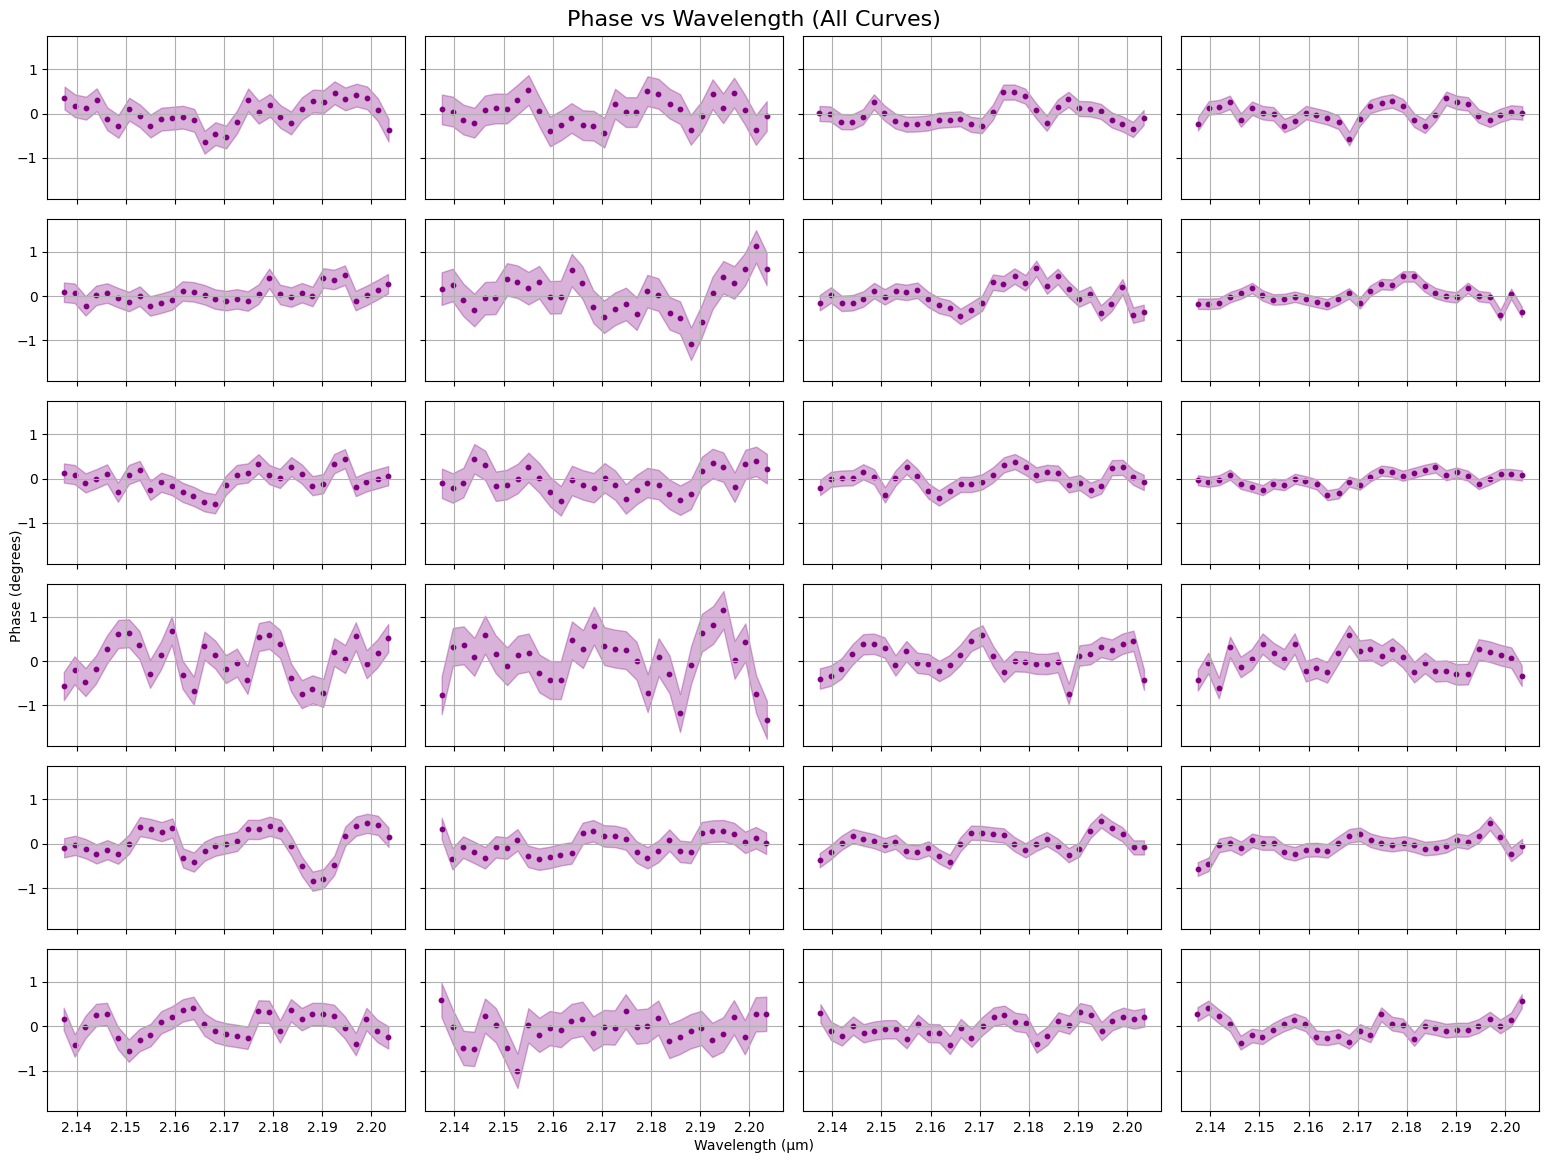

In [9]:
fig, axes = plt.subplots(6, 4, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten() # flatten to iterate easily

for i in range(24):
    ax = axes[i]
    ax.scatter(wavelength_phase[i*31:(i+1)*31], phase[i*31:(i+1)*31], s=10, label='Phase', color='purple')
    ax.fill_between(wavelength_phase[i*31:(i+1)*31], phase[i*31:(i+1)*31] - err_phase[i*31:(i+1)*31], phase[i*31:(i+1)*31] + err_phase[i*31:(i+1)*31], alpha=0.3, color='purple')
    # ax.set_title(f'Curve {i+1}', fontsize=10)
    ax.grid(True)

# Shared labels
fig.text(0.5, 0.03, 'Wavelength (µm)', ha='center')
fig.text(0.035, 0.5, 'Phase (degrees)', va='center', rotation='vertical')
fig.suptitle('Phase vs Wavelength (All Curves)', fontsize=16)
plt.tight_layout(rect=[0.03, 0.03, 1, 1])
plt.show()

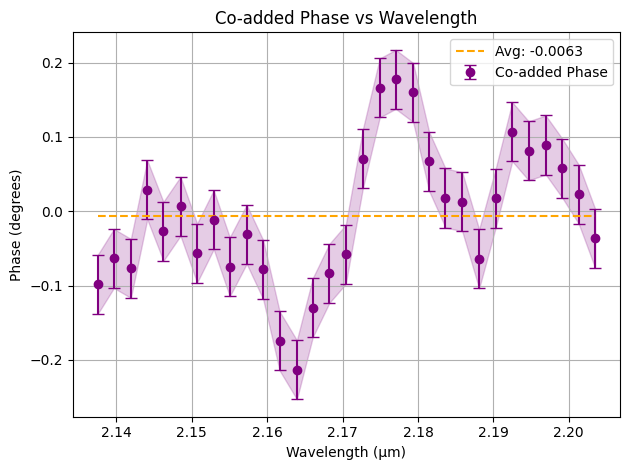

In [10]:
n_curves = 24
n_points = 31

# Reshape arrays
phase_2d = phase.reshape(n_curves, n_points)
err_2d = err_phase.reshape(n_curves, n_points)
wavelength_2d = wavelength_phase.reshape(n_curves, n_points)

# For co-adding, assume all wavelength rows are identical (or nearly so)
# You can take the first row
wavelength = wavelength_2d[0]

# Compute inverse variance weights
weights = 1.0 / err_2d**2

# Weighted average and error
weighted_sum = np.sum(weights * phase_2d, axis=0)
weight_total = np.sum(weights, axis=0)

coadd_phase = weighted_sum / weight_total
coadd_error = 1.0 / np.sqrt(weight_total)

# Plot the co-added phase
plt.errorbar(wavelength, coadd_phase, yerr=coadd_error, fmt='o', capsize=4, color='purple', label='Co-added Phase')
plt.fill_between(wavelength, coadd_phase-coadd_error, coadd_phase+coadd_error, color='purple', alpha=0.2)
plt.hlines(np.average(coadd_phase), wavelength[0], wavelength[-1], color='orange', ls='dashed', label=f'Avg: {np.average(coadd_phase):.4f}')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Phase (degrees)')
plt.title('Co-added Phase vs Wavelength')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Code which adds evenly spaced epochs to the phase_data file.
input_file = "../RM Data/phase_data_G.txt"
output_file = "../RM Data/phase_data_epochs.txt"

n_groups = 24
n_rows_per_epoch = 31
epoch_spacing = 0.5 # Or whatever spacing your simulation uses
start_epoch = 5800

with open(input_file, 'r') as fin, open(output_file, 'w') as fout:
    fout.write(f'# {n_groups} {n_rows_per_epoch}\n')
    lines = [line.strip() for line in fin if line.strip()]  # Ignore blank lines
    n_epochs = len(lines) // n_rows_per_epoch

    for i in range(n_epochs):
        epoch_value = start_epoch + i * epoch_spacing
        fout.write(f"# {epoch_value:.6f}\n")
        for j in range(n_rows_per_epoch):
            fout.write(lines[i * n_rows_per_epoch + j] + "\n")
        fout.write("\n")  # Optional blank line between epochs

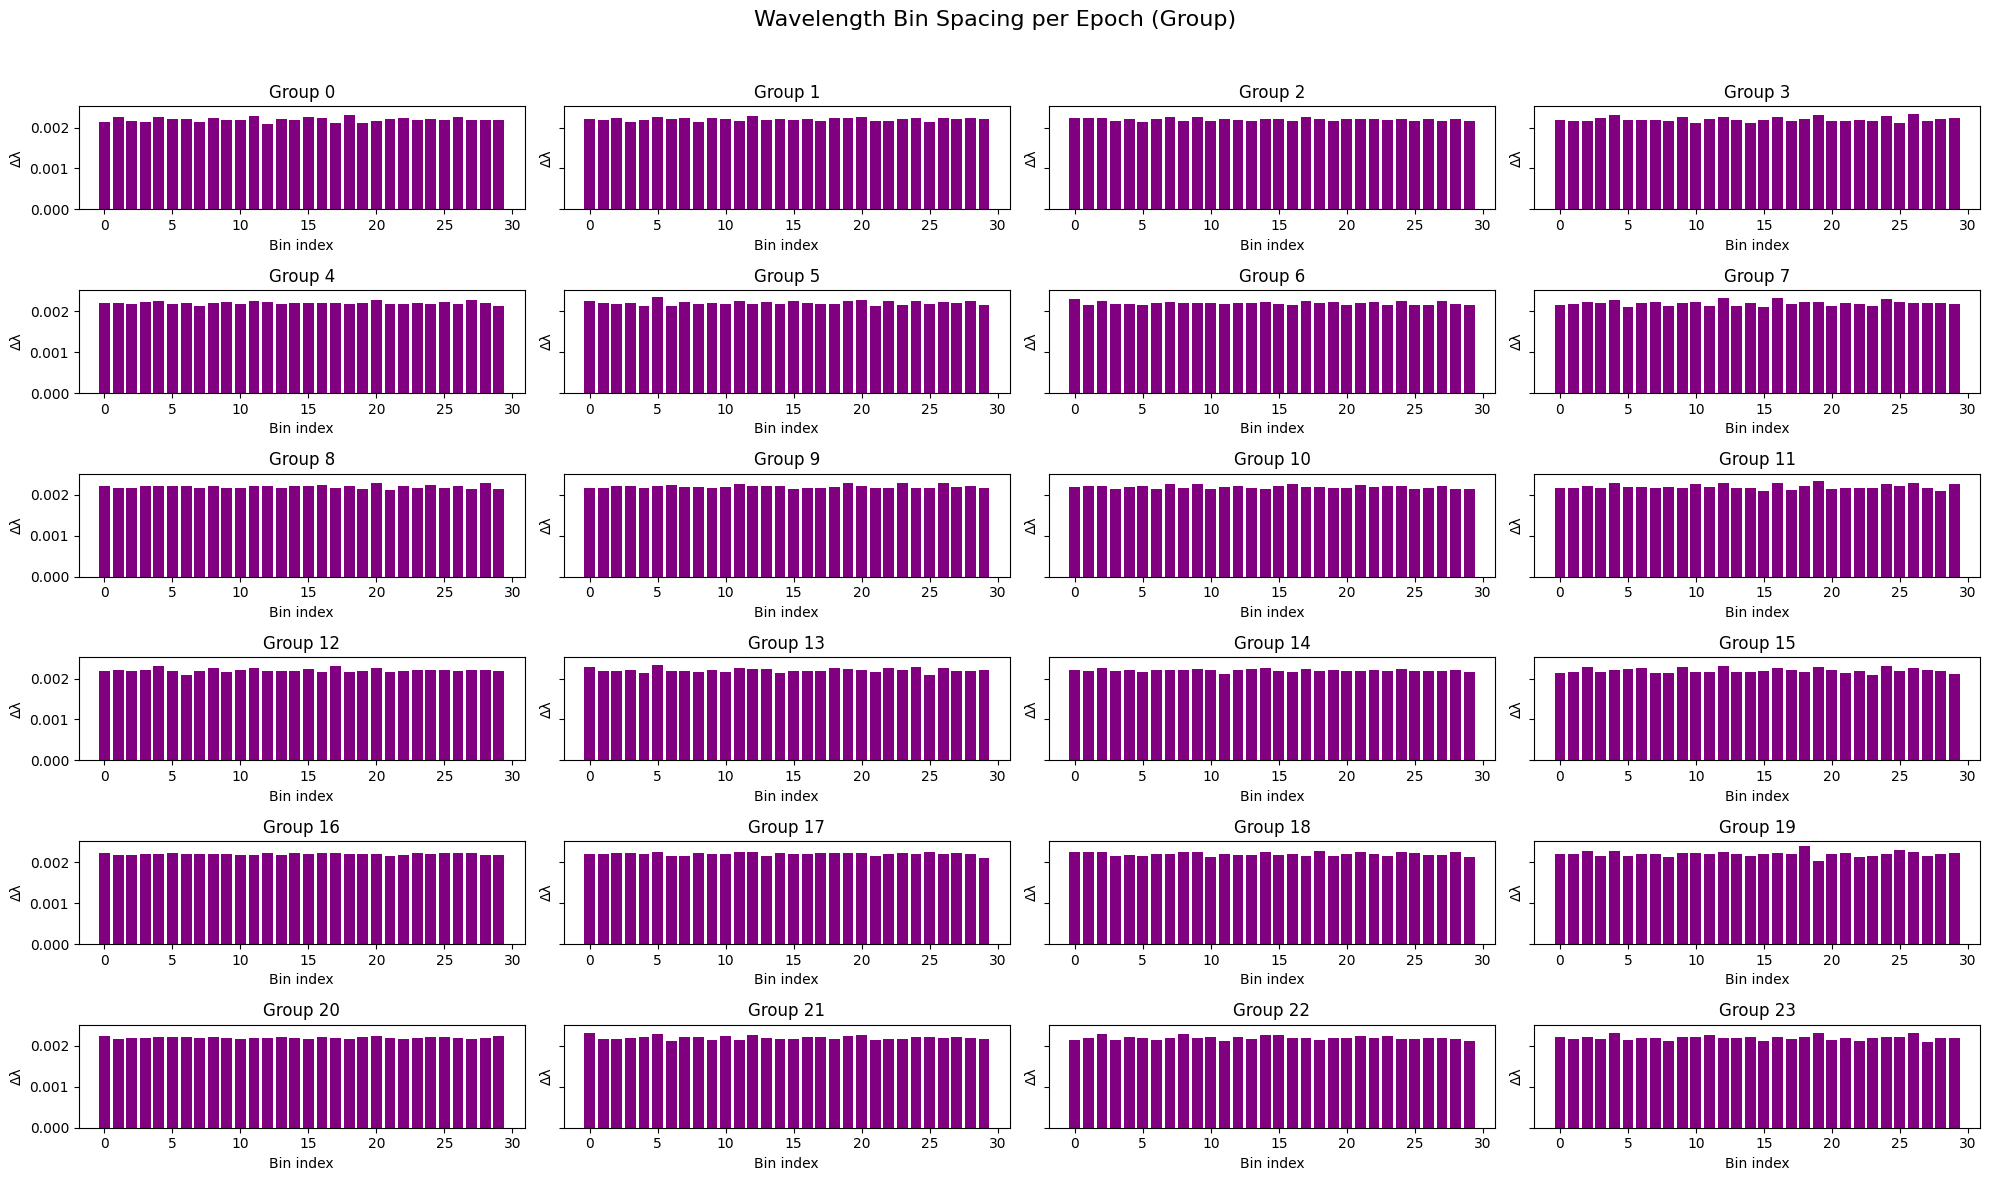

In [ ]:
# shows the wavelength bin differences between each. They should be perfectly uniform apparently
wavelengths_reshaped = wavelength_phase.reshape(24, 31)

# Compute spacing per group
delta_wavelengths = np.diff(wavelengths_reshaped, axis=1)  # shape (24, 30)

# Plot
fig, axs = plt.subplots(6, 4, figsize=(20, 12), sharey=True)
fig.suptitle("Wavelength Bin Spacing per Epoch (Group)", fontsize=16)

for idx in range(24):
    ax = axs[idx // 4, idx % 4]
    ax.bar(range(30), delta_wavelengths[idx], color='purple')
    ax.set_title(f"Group {idx+1}")
    ax.set_xlabel("Bin index")
    ax.set_ylabel("Δλ")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

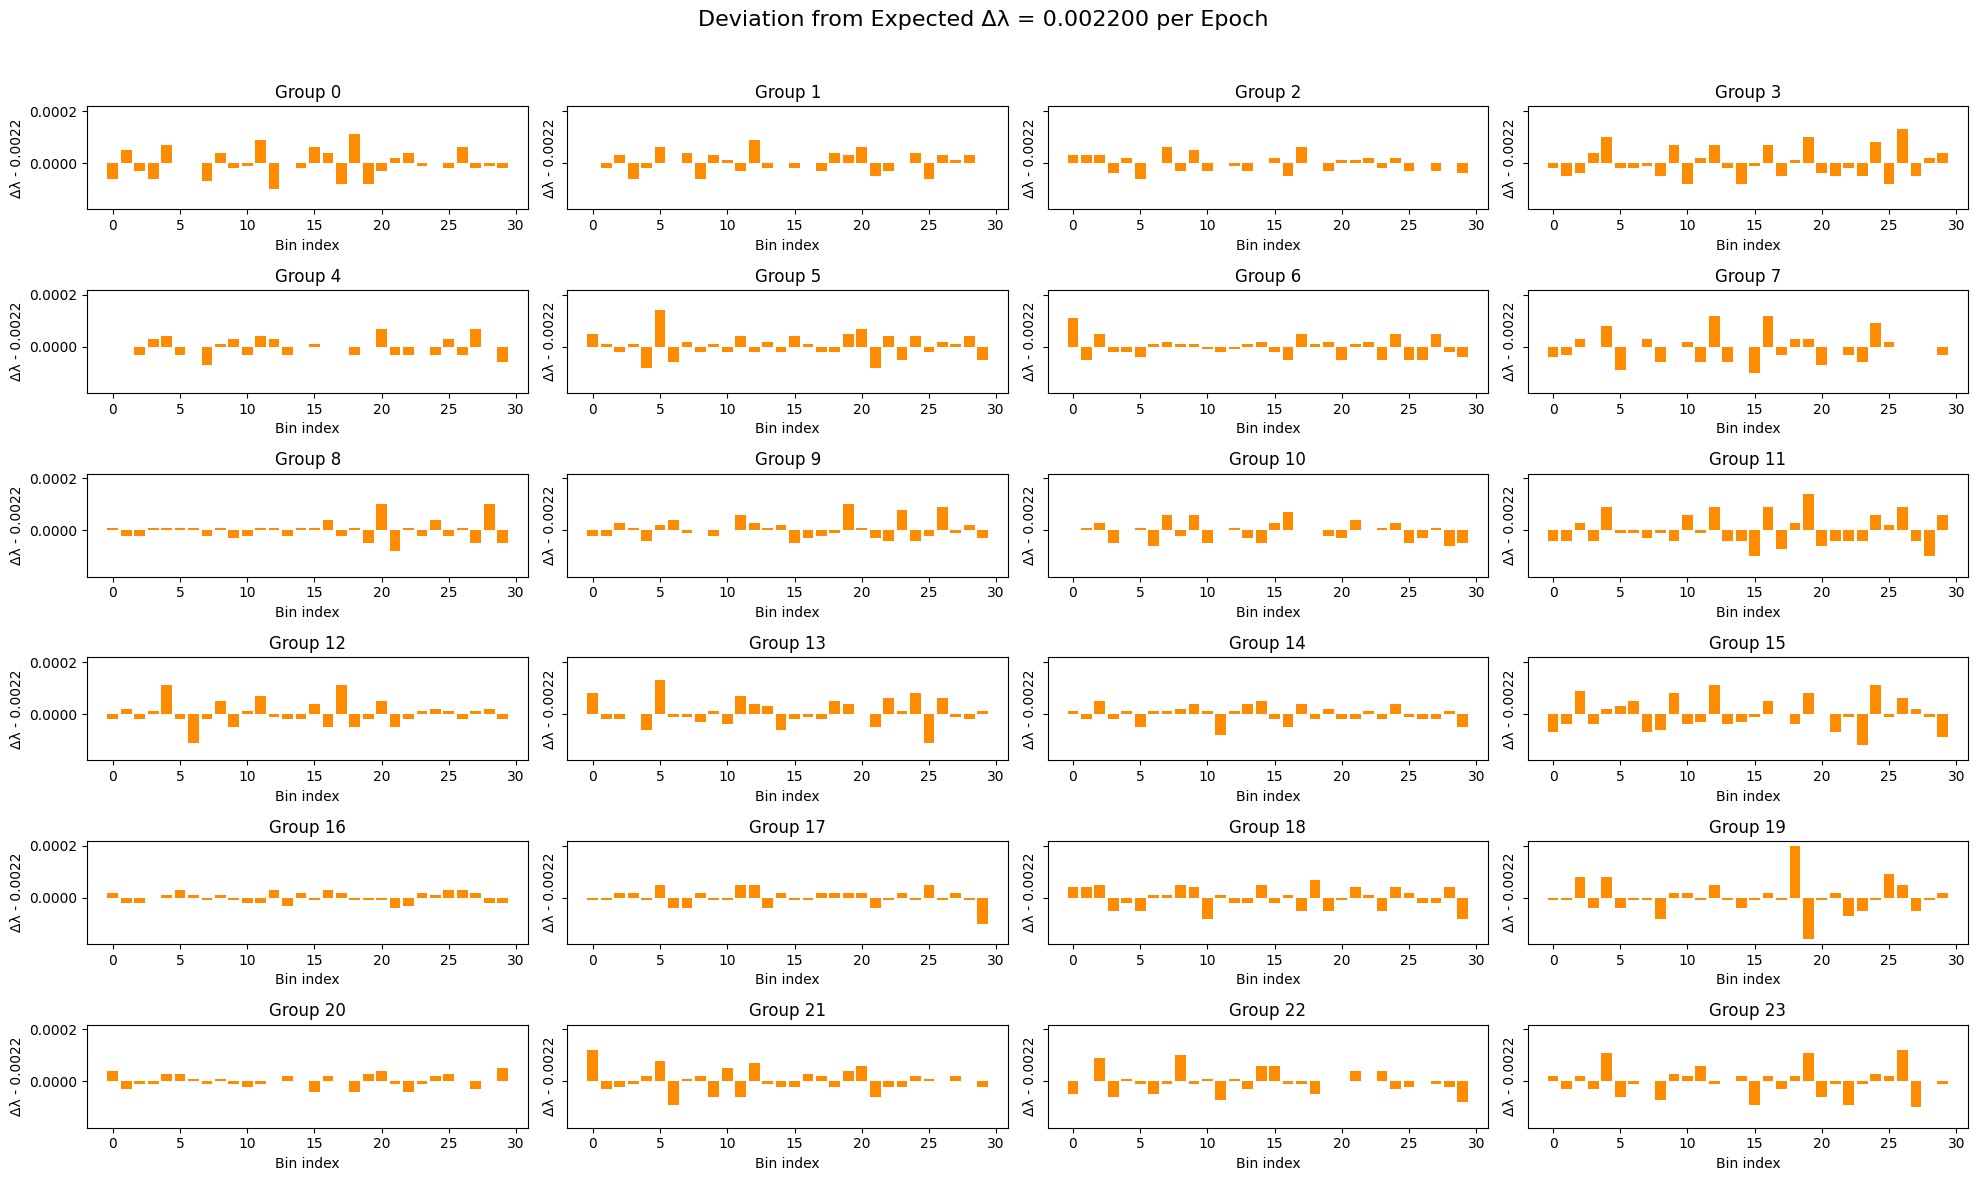

In [ ]:
# Compute deviation from expected spacing
expected_delta = 0.002200
delta_deviation = delta_wavelengths - expected_delta

# Plot
fig, axs = plt.subplots(6, 4, figsize=(20, 12), sharey=True)
fig.suptitle("Deviation from Expected Δλ = 0.002200 per Epoch", fontsize=16)

for idx in range(24):
    ax = axs[idx // 4, idx % 4]
    ax.bar(range(30), delta_deviation[idx], color='darkorange')
    ax.set_title(f"Group {idx+1}")
    ax.set_xlabel("Bin index")
    ax.set_ylabel("Δλ - 0.0022")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

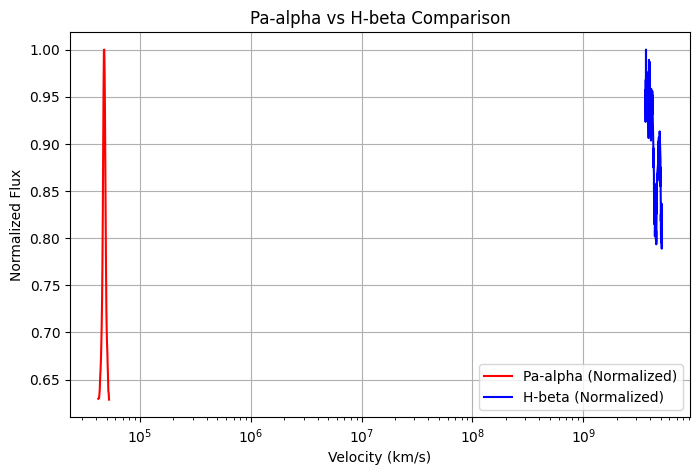

In [ ]:
# Compare with H-beta and continuum (Assuming files exist)
try:
    wavelength_hb, flux_hb, err_flux_hb = load_data('../RM Data/3C273_hb_7yr.txt', cols=3)
    wavelength_cont, flux_cont, err_flux_cont = load_data('../RM Data/3C273_con_7yr.txt', cols=3)
    
    velocity_hb = c_kms * (wavelength_hb - lambda_h_beta) / lambda_h_beta
    
    plt.figure(figsize=(8,5))
    plt.plot(velocity_pa, flux_pa / np.max(flux_pa), label='Pa-alpha (Normalized)', color='red')
    plt.semilogx(velocity_hb, flux_hb / np.max(flux_hb), label='H-beta (Normalized)', color='blue')
    plt.xlabel('Velocity (km/s)')
    plt.ylabel('Normalized Flux')
    plt.title('Pa-alpha vs H-beta Comparison')
    plt.legend()
    plt.grid()
    plt.show()
    
except FileNotFoundError:
    print("H-beta or Continuum file not found. Skipping comparison.")

# print("Processing complete.")

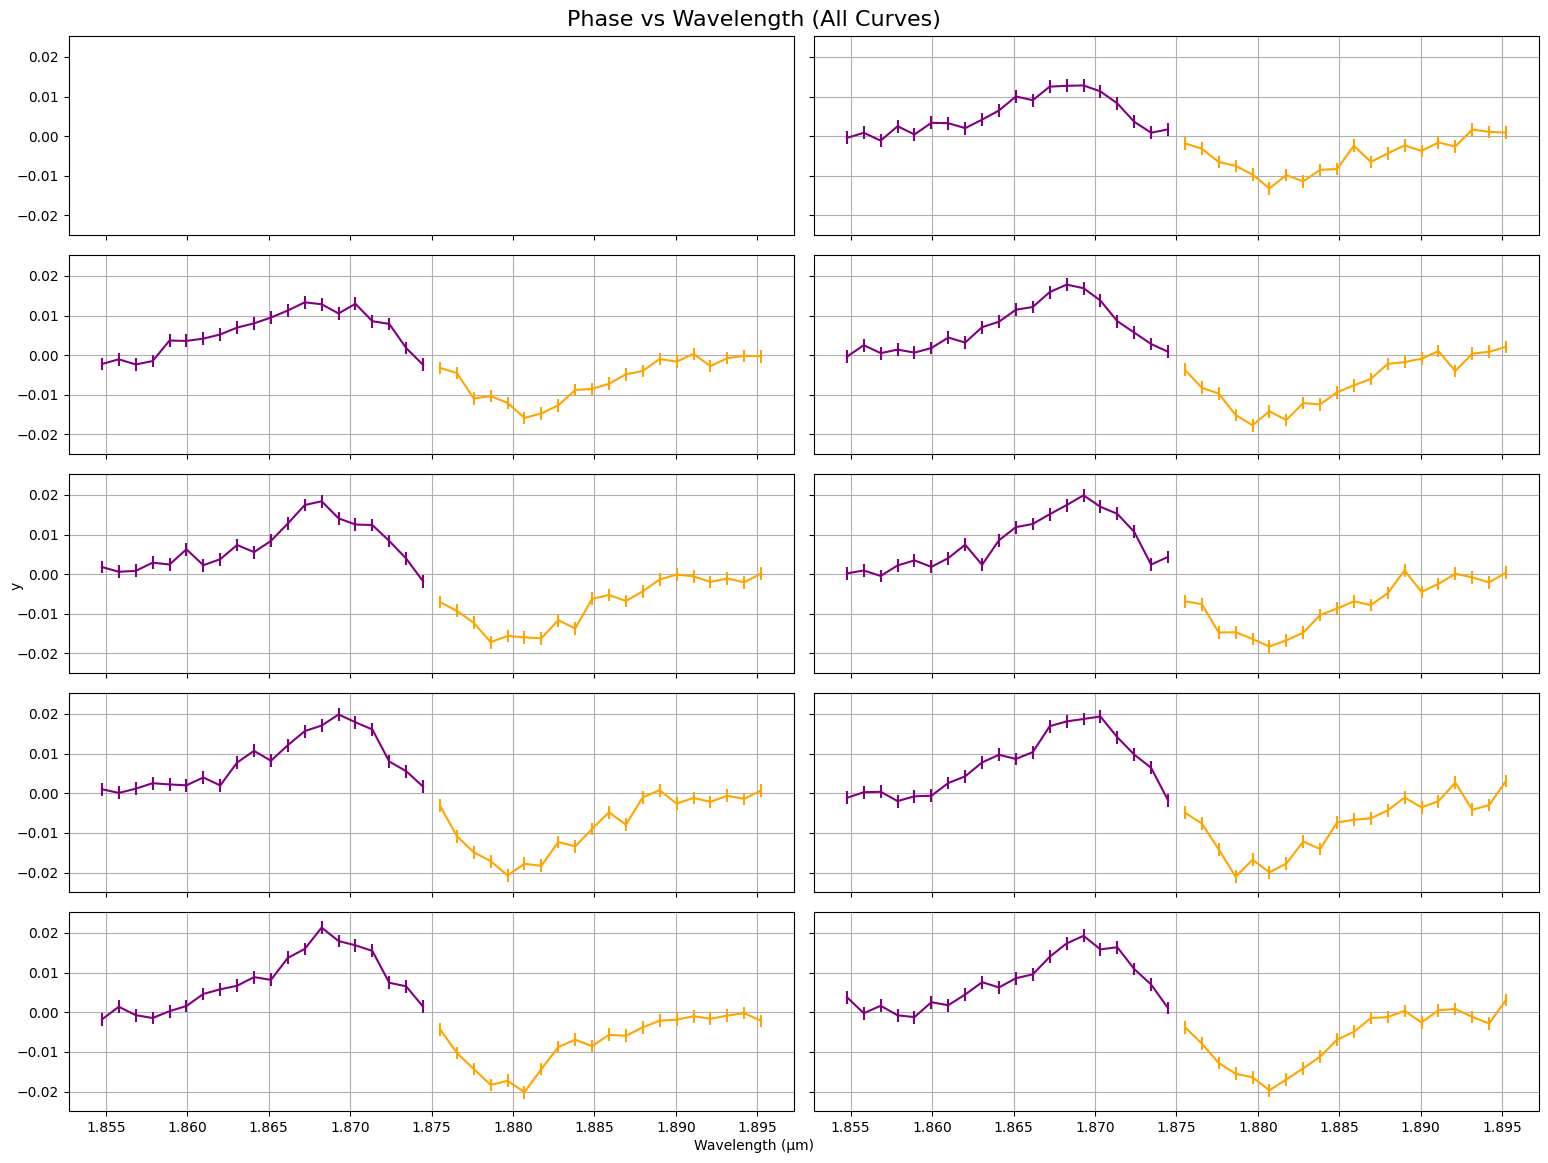

In [ ]:
# plot each of the data groups in the sim_sa file
sa = np.genfromtxt(r'//wsl$/Ubuntu-22.04/home/alice/brains/BRAINS/data/sim_sa.txt')
sa_1 = sa[:, 0]
sa_2 = sa[:, 1]
sa_3 = sa[:, 2]

fig, axes = plt.subplots(5, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten() # flatten to iterate easily

ax = axes[0]

for i in range(0, 10):
    ax = axes[i]
    i = 2*i
    ax.errorbar(sa_1[i*20:(i+1)*20], sa_2[i*20:(i+1)*20], yerr=sa_3[i*20:(i+1)*20], label='Phase', color='purple')
    ax.errorbar(sa_1[(i+1)*20:((i+1)+1)*20], sa_2[(i+1)*20:((i+1)+1)*20], yerr=sa_3[(i+1)*20:((i+1)+1)*20], label='Phase', color='orange')
    ax.grid(True)

# Shared labels
fig.text(0.5, 0.03, 'Wavelength (µm)', ha='center')
fig.text(0.035, 0.5, 'y', va='center', rotation='vertical')
fig.suptitle('Sim SA data', fontsize=16)
plt.tight_layout(rect=[0.03, 0.03, 1, 1])
plt.show()

In [27]:
# 24/06 add baselines to phase_data_G to use in SA mode.
input_file = "../RM Data/phase_data_G.txt"
output_file = "../RM Data/phase_data_G_baselines.txt"

baselines = np.genfromtxt('../RM Data/base_G.txt')

n_groups = 24
rows_per_group = 31

with open(input_file, 'r') as fin, open(output_file, 'w') as fout:
    fout.write(f'# 1 {rows_per_group} {n_groups}\n')
    lines = [line.strip() for line in fin if line.strip()]  # Ignore blank lines

    for i in range(n_groups):
        base = f'{baselines[i][0]} {baselines[i][1]}'
        fout.write(f"# {base}\n")
        for j in range(rows_per_group):
            fout.write(lines[i * rows_per_group + j] + "\n")
        fout.write("\n")  # blank line between epochs

In [28]:
# 26/06 validating phase_data_G to be used with SA mode.
def scan_for_malformed_data(filepath):
    with open(filepath) as f:
        lines = [line.strip() for line in f if line.strip()]

    header = list(map(int, lines[0][1:].strip().split()))
    mode, n_vel, n_baselines = header

    i = 1
    for b in range(n_baselines):
        line = lines[i]
        if not line.startswith("#"):
            print(f"Missing baseline header at block {b}, line {i+1}")
            return
        i += 1
        for j in range(n_vel):
            if i >= len(lines):
                print(f"Unexpected EOF in block {b}, row {j}")
                return
            parts = lines[i].split()
            if len(parts) != 3:
                print(f"Block {b}, row {j}, line {i+1}: expected 3 values, got {len(parts)}: {lines[i]}")
                return
            i += 1
    print("All blocks and data rows are properly formatted.")

scan_for_malformed_data(output_file)

All blocks and data rows are properly formatted.
